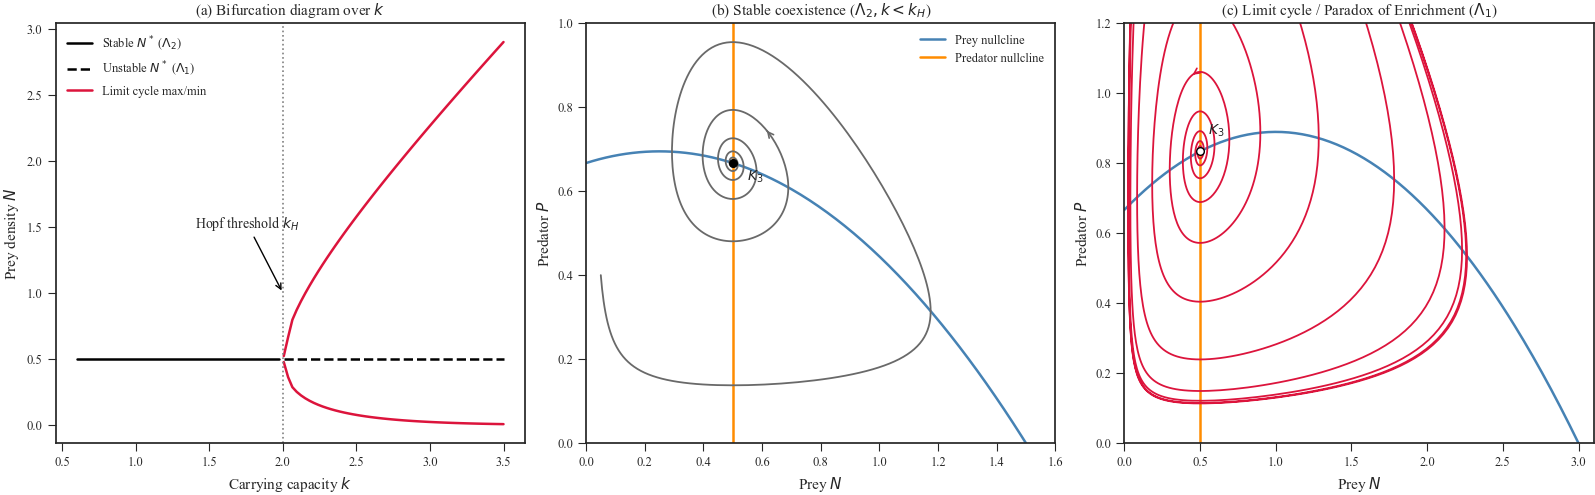

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from pathlib import Path
from IPython.display import display, IFrame

# ==========================================
# 0. Output paths
# ==========================================
desktop = Path(r"C:\Users\lenovo\OneDrive - Northeastern University\桌面")
desktop.mkdir(parents=True, exist_ok=True)

eps_path = desktop / "Fig1.eps"
pdf_path = desktop / "Fig1_preview.pdf"

# ==========================================
# 1. Model Parameters & Definitions
# ==========================================
m = 1.5   # Predation/assimilation rate
c = 0.5   # Predator mortality rate
# Equilibrium prey density (N*) and Hopf carrying capacity (k_H)
N_star = c / (m - c)
k_H = (m + c) / (m - c)

def rm_ode(t, y, k):
    """Deterministic Rosenzweig-MacArthur ODE system."""
    N, P = y
    # Prevent negative populations during numerical integration
    N = max(0, N)
    P = max(0, P)
    dN = N * (1 - N/k) - (m * N * P) / (1 + N)
    dP = P * (-c + (m * N) / (1 + N))
    return [dN, dP]

def get_P_star(k):
    """Calculates the equilibrium predator density."""
    return (1 / m) * (1 - N_star / k) * (1 + N_star)

def prey_nullcline(N, k):
    """Prey nullcline: P as a function of N."""
    return (1 / m) * (1 - N / k) * (1 + N)

# ==========================================
# 2. Figure Setup
# ==========================================
# More journal-friendly font settings
plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 10,
    "axes.labelsize": 11,
    "axes.titlesize": 11,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "pdf.fonttype": 42,   # embed TrueType fonts
    "ps.fonttype": 42,    # embed TrueType fonts
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
    "axes.unicode_minus": False,
})

fig, axes = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)

# ==========================================
# Panel (a): 1D Bifurcation Diagram over k
# ==========================================
ax = axes[0]
k_vals = np.linspace(0.6, 3.5, 100)
N_max_env = []
N_min_env = []

# Simulate to find the limit cycle amplitudes
for k in k_vals:
    if k <= k_H:
        N_max_env.append(N_star)
        N_min_env.append(N_star)
    else:
        # Initial condition slightly perturbed from equilibrium
        P_eq = get_P_star(k)
        y0 = [N_star + 0.01, P_eq + 0.01]

        # Integrate over a long time to reach the attractor
        t_span = (0, 1000)
        # Use denser sampling for the tail to perfectly capture peaks
        t_eval = np.linspace(800, 1000, 5000)

        sol = solve_ivp(
            rm_ode, t_span, y0, args=(k,), t_eval=t_eval,
            method='BDF', rtol=1e-8, atol=1e-10
        )

        N_max_env.append(np.max(sol.y[0]))
        N_min_env.append(np.min(sol.y[0]))

stable_mask = k_vals <= k_H
unstable_mask = k_vals > k_H

ax.plot(k_vals[stable_mask], [N_star] * np.sum(stable_mask),
        'k-', lw=1.8, label=r'Stable $N^*$ ($\Lambda_2$)')
ax.plot(k_vals[unstable_mask], [N_star] * np.sum(unstable_mask),
        'k--', lw=1.8, label=r'Unstable $N^*$ ($\Lambda_1$)')

ax.plot(k_vals[unstable_mask], np.array(N_max_env)[unstable_mask],
        color='crimson', lw=1.8, label='Limit cycle max/min')
ax.plot(k_vals[unstable_mask], np.array(N_min_env)[unstable_mask],
        color='crimson', lw=1.8)

ax.axvline(k_H, color='gray', linestyle=':', lw=1.2)
ax.annotate(r'Hopf threshold $k_H$', xy=(k_H, 1.0), xytext=(k_H - 0.6, 1.5),
            arrowprops=dict(facecolor='black', arrowstyle='->', lw=1.0))

ax.set_title(r'(a) Bifurcation diagram over $k$')
ax.set_xlabel(r'Carrying capacity $k$')
ax.set_ylabel(r'Prey density $N$')
ax.legend(loc='upper left', frameon=False)

# ==========================================
# Panel (b): Phase Portrait for \Lambda_2 (Stable)
# ==========================================
ax = axes[1]
k_stable = 1.5
P_eq_stable = get_P_star(k_stable)

# Nullclines
N_range = np.linspace(0, k_stable, 200)
ax.plot(N_range, prey_nullcline(N_range, k_stable), color='steelblue', lw=1.8, label='Prey nullcline')
ax.axvline(N_star, color='darkorange', lw=1.8, label='Predator nullcline')

# Trajectory
t_span = (0, 100)
sol_stable = solve_ivp(
    rm_ode, t_span, [0.05, 0.4], args=(k_stable,),
    dense_output=True, max_step=0.1
)
ax.plot(sol_stable.y[0], sol_stable.y[1], color='dimgray', lw=1.3)

# Arrow indicating direction
idx = len(sol_stable.y[0]) // 4
ax.annotate(
    '', xy=(sol_stable.y[0, idx + 1], sol_stable.y[1, idx + 1]),
    xytext=(sol_stable.y[0, idx], sol_stable.y[1, idx]),
    arrowprops=dict(arrowstyle='->', color='dimgray', lw=1.2)
)

ax.plot(N_star, P_eq_stable, 'ko', markersize=5.5, zorder=5)
ax.text(N_star + 0.05, P_eq_stable - 0.04, r'$K_3$', fontweight='bold')

ax.set_xlim(0, k_stable + 0.1)
ax.set_ylim(0, 1)
ax.set_title(r'(b) Stable coexistence ($\Lambda_2, k < k_H$)')
ax.set_xlabel(r'Prey $N$')
ax.set_ylabel(r'Predator $P$')
ax.legend(loc='upper right', frameon=False)

# ==========================================
# Panel (c): Phase Portrait for \Lambda_1 (Limit Cycle)
# ==========================================
ax = axes[2]
k_unstable = 3.0
P_eq_unstable = get_P_star(k_unstable)

# Nullclines
N_range = np.linspace(0, k_unstable, 200)
ax.plot(N_range, prey_nullcline(N_range, k_unstable), color='steelblue', lw=1.8)
ax.axvline(N_star, color='darkorange', lw=1.8)

# Trajectory spiraling outward
t_span = (0, 150)
y0_unstable = [N_star + 0.01, P_eq_unstable + 0.01]
sol_unstable = solve_ivp(
    rm_ode, t_span, y0_unstable, args=(k_unstable,),
    dense_output=True, max_step=0.1
)

ax.plot(sol_unstable.y[0], sol_unstable.y[1], color='crimson', lw=1.3)

# Arrow indicating direction
idx = len(sol_unstable.y[0]) // 3
ax.annotate(
    '', xy=(sol_unstable.y[0, idx + 1], sol_unstable.y[1, idx + 1]),
    xytext=(sol_unstable.y[0, idx], sol_unstable.y[1, idx]),
    arrowprops=dict(arrowstyle='->', color='crimson', lw=1.2)
)

# Equilibrium point (unstable)
ax.plot(N_star, P_eq_unstable, 'wo', markeredgecolor='k', markersize=5.5, zorder=5)
ax.text(N_star + 0.05, P_eq_unstable + 0.05, r'$K_3$', fontweight='bold')

ax.set_xlim(0, k_unstable + 0.1)
ax.set_ylim(0, 1.2)
ax.set_title(r'(c) Limit cycle / Paradox of Enrichment ($\Lambda_1$)')
ax.set_xlabel(r'Prey $N$')
ax.set_ylabel(r'Predator $P$')

# ==========================================
# 3. Save as PDF preview and EPS final output
# ==========================================
# PDF for notebook inspection
fig.savefig(pdf_path, format='pdf')

# EPS for submission
fig.savefig(eps_path, format='eps')

# Show the preview PDF below the cell
display(IFrame(str(pdf_path), width=1100, height=700))

plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


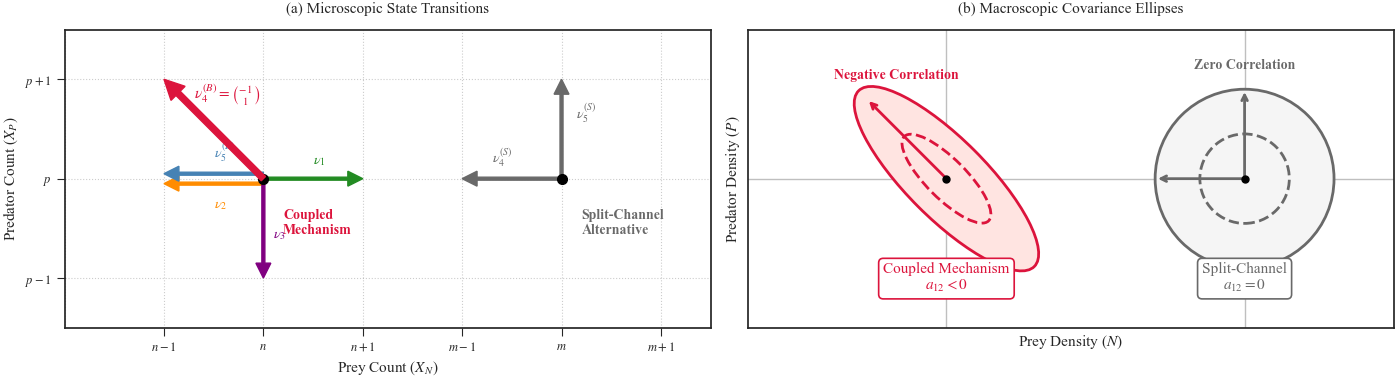

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from pathlib import Path
from IPython.display import display, IFrame

# ==========================================
# Output paths
# ==========================================
desktop = Path(r"C:\Users\lenovo\OneDrive - Northeastern University\桌面")
desktop.mkdir(parents=True, exist_ok=True)

eps_path = desktop / "Fig2.eps"
pdf_path = desktop / "Fig2_preview.pdf"

# ==========================================
# Figure Setup (PLOS-friendly style)
# ==========================================
plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "mathtext.fontset": "stix",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
    "axes.unicode_minus": False
})

fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

# ==========================================
# Panel (a): Microscopic State Transition Lattice
# ==========================================
ax1 = axes[0]
ax1.set_xlim(-2, 4.5)
ax1.set_ylim(-1.5, 1.5)
ax1.set_aspect('equal')

# Draw background lattice grid
for i in range(-2, 6):
    ax1.axvline(i, color='gray', linestyle=':', alpha=0.4, lw=0.8)
for i in range(-2, 3):
    ax1.axhline(i, color='gray', linestyle=':', alpha=0.4, lw=0.8)

# --- 1. Coupled Mechanism Node ---
center1 = (0, 0)
ax1.plot(*center1, 'ko', markersize=7, zorder=5)
ax1.text(0.2, -0.3, 'Coupled\nMechanism', ha='left', va='top',
         fontweight='bold', color='crimson')

# Standard Jump Vectors
opts = dict(width=0.03, head_width=0.15, head_length=0.15,
            length_includes_head=True, zorder=4)
ax1.arrow(0, 0, 1, 0, color='forestgreen', **opts)      # v1: Prey birth
ax1.arrow(0, -0.05, -1, 0, color='darkorange', **opts)  # v2: Prey death
ax1.arrow(0, 0.05, -1, 0, color='steelblue', **opts)    # v5: Unsuccessful predation
ax1.arrow(0, 0, 0, -1, color='purple', **opts)          # v3: Predator death

# Highlighted v4: Coupled Predation-Conversion
ax1.arrow(0, 0, -1, 1, color='crimson', width=0.06,
          head_width=0.2, head_length=0.2,
          length_includes_head=True, zorder=5)

ax1.text(0.5, 0.15, r'$\nu_1$', color='forestgreen')
ax1.text(-0.5, -0.3, r'$\nu_2$', color='darkorange')
ax1.text(-0.5, 0.2, r'$\nu_5^{(B)}$', color='steelblue')
ax1.text(0.1, -0.6, r'$\nu_3$', color='purple')
ax1.text(-0.7, 0.8, r'$\nu_4^{(B)} = \binom{-1}{1}$',
         color='crimson', fontweight='bold', fontsize=11)

# --- 2. Split-Channel Node ---
center2 = (3, 0)
ax1.plot(*center2, 'ko', markersize=7, zorder=5)
ax1.text(3.2, -0.3, 'Split-Channel\nAlternative', ha='left', va='top',
         fontweight='bold', color='dimgray')

# Orthogonal Vectors
ax1.arrow(3, 0, -1, 0, color='dimgray', **opts)  # v_s1: Independent prey death
ax1.arrow(3, 0, 0, 1, color='dimgray', **opts)   # v_s2: Independent predator birth
ax1.text(2.3, 0.15, r'$\nu_4^{(S)}$', color='dimgray')
ax1.text(3.15, 0.6, r'$\nu_5^{(S)}$', color='dimgray')

ax1.set_title(r'(a) Microscopic State Transitions', pad=12)
ax1.set_xlabel(r'Prey Count ($X_N$)')
ax1.set_ylabel(r'Predator Count ($X_P$)')
ax1.set_xticks([-1, 0, 1, 2, 3, 4])
ax1.set_xticklabels([r'$n-1$', r'$n$', r'$n+1$', r'$m-1$', r'$m$', r'$m+1$'])
ax1.set_yticks([-1, 0, 1])
ax1.set_yticklabels([r'$p-1$', r'$p$', r'$p+1$'])

# ==========================================
# Panel (b): Macroscopic Covariance Geometry
# ==========================================
ax2 = axes[1]
ax2.set_xlim(-2, 4.5)
ax2.set_ylim(-1.5, 1.5)
ax2.set_aspect('equal')

# Faint reference axes
ax2.axvline(0, color='gray', lw=1, alpha=0.5)
ax2.axhline(0, color='gray', lw=1, alpha=0.5)
ax2.axvline(3, color='gray', lw=1, alpha=0.5)

# --- 1. Coupled Ellipses (tilted) ---
# No transparency for EPS safety
e1_out = Ellipse(
    xy=(0, 0), width=2.5, height=0.8, angle=-45,
    edgecolor='crimson', facecolor='mistyrose', alpha=1.0, lw=2, zorder=2
)
e1_in = Ellipse(
    xy=(0, 0), width=1.2, height=0.4, angle=-45,
    edgecolor='crimson', facecolor='none', lw=2, ls='--', zorder=3
)
ax2.add_patch(e1_out)
ax2.add_patch(e1_in)
ax2.plot(0, 0, 'ko', ms=5, zorder=4)

ax2.annotate('', xy=(-0.8, 0.8), xytext=(0, 0),
             arrowprops=dict(arrowstyle='->', color='crimson', lw=2))
ax2.text(-0.5, 1.0, 'Negative Correlation', color='crimson',
         fontweight='bold', ha='center')

bbox1 = dict(boxstyle="round,pad=0.3", fc="white", ec="crimson", lw=1.2)
ax2.text(0, -1.0, r'Coupled Mechanism' '\n' r'$a_{12} < 0$',
         ha='center', va='center', color='crimson', fontsize=11, bbox=bbox1)

# --- 2. Split-Channel Ellipses (axes-aligned) ---
e2_out = Ellipse(
    xy=(3, 0), width=1.8, height=1.8, angle=0,
    edgecolor='dimgray', facecolor='whitesmoke', alpha=1.0, lw=2, zorder=2
)
e2_in = Ellipse(
    xy=(3, 0), width=0.9, height=0.9, angle=0,
    edgecolor='dimgray', facecolor='none', lw=2, ls='--', zorder=3
)
ax2.add_patch(e2_out)
ax2.add_patch(e2_in)
ax2.plot(3, 0, 'ko', ms=5, zorder=4)

ax2.annotate('', xy=(2.1, 0), xytext=(3, 0),
             arrowprops=dict(arrowstyle='->', color='dimgray', lw=2))
ax2.annotate('', xy=(3, 0.9), xytext=(3, 0),
             arrowprops=dict(arrowstyle='->', color='dimgray', lw=2))
ax2.text(3, 1.1, 'Zero Correlation', color='dimgray',
         fontweight='bold', ha='center')

bbox2 = dict(boxstyle="round,pad=0.3", fc="white", ec="dimgray", lw=1.2)
ax2.text(3, -1.0, r'Split-Channel' '\n' r'$a_{12} = 0$',
         ha='center', va='center', color='dimgray', fontsize=11, bbox=bbox2)

ax2.set_title(r'(b) Macroscopic Covariance Ellipses', pad=12)
ax2.set_xlabel(r'Prey Density ($N$)')
ax2.set_ylabel(r'Predator Density ($P$)')
ax2.set_xticks([])
ax2.set_yticks([])

# ==========================================
# Save as PDF preview and EPS final output
# ==========================================
fig.savefig(pdf_path, format='pdf')
fig.savefig(eps_path, format='eps')

# Show PDF preview below the cell
display(IFrame(str(pdf_path), width=1100, height=700))

plt.show()

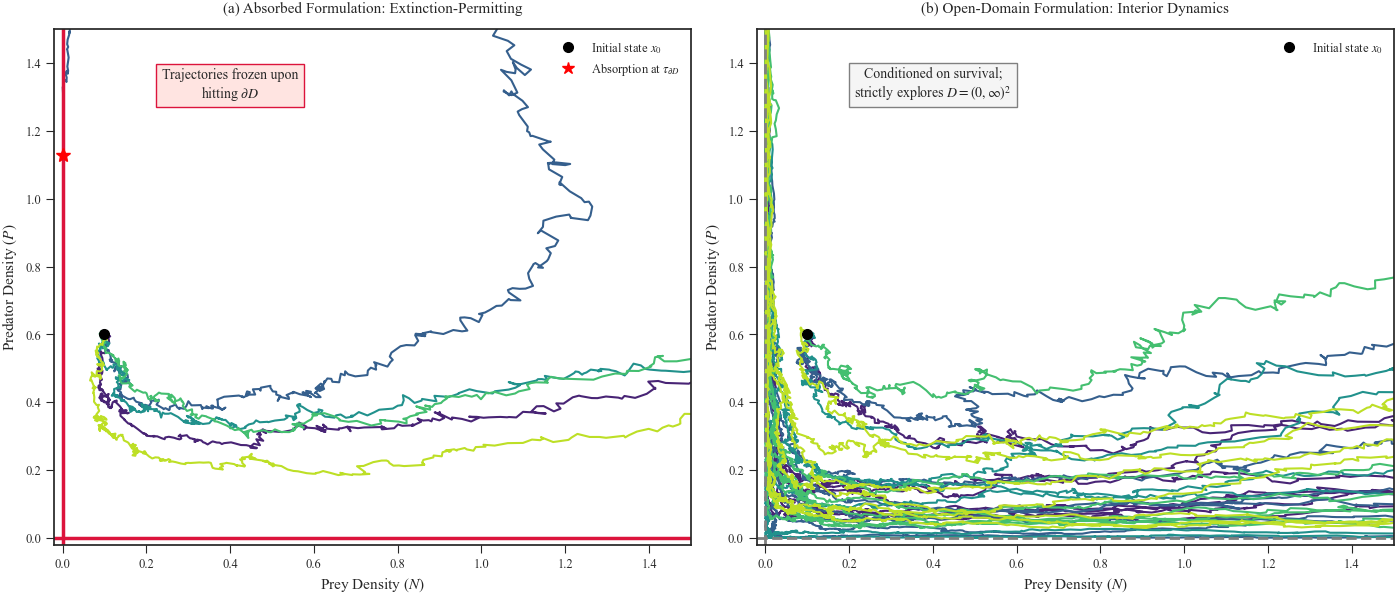

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display, IFrame

# ==========================================
# Output paths
# ==========================================
desktop = Path(r"C:\Users\lenovo\OneDrive - Northeastern University\桌面")
desktop.mkdir(parents=True, exist_ok=True)

eps_path = desktop / "Fig3.eps"
pdf_path = desktop / "Fig3_preview.pdf"

# ==========================================
# 1. Model Parameters & CLE Setup
# ==========================================
m = 1.5
c = 0.4
k = 5.5
Omega = 150.0  # System size (fluctuation-amplified regime)

def get_diffusion_cholesky(N, P):
    """Calculate the Cholesky factor L of the covariance matrix a(x)."""
    N = max(0.0, N)
    P = max(0.0, P)

    f_pred = (m * N * P) / (1 + N)
    a11 = (N + (N**2) / k + f_pred) / Omega
    a22 = (c * P + f_pred) / Omega
    a12 = -f_pred / Omega

    eps = 1e-12
    a11 += eps
    a22 += eps

    L11 = np.sqrt(a11)
    L21 = a12 / L11
    L22 = np.sqrt(max(0.0, a22 - L21**2))

    return np.array([[L11, 0.0], [L21, L22]])

def simulate_cle(N0, P0, dt, steps, mode='absorbed'):
    """Simulate the CLE with specific boundary rules."""
    N = np.zeros(steps)
    P = np.zeros(steps)
    N[0], P[0] = N0, P0

    hit_boundary = False
    hit_idx = steps - 1

    for i in range(1, steps):
        curr_N = N[i - 1]
        curr_P = P[i - 1]

        # Deterministic drift
        dN = curr_N * (1 - curr_N / k) - (m * curr_N * curr_P) / (1 + curr_N)
        dP = curr_P * (-c + (m * curr_N) / (1 + curr_N))

        # Stochastic diffusion
        L = get_diffusion_cholesky(curr_N, curr_P)
        dW = np.random.normal(0, np.sqrt(dt), 2)
        diffusion = L @ dW

        next_N = curr_N + dN * dt + diffusion[0]
        next_P = curr_P + dP * dt + diffusion[1]

        # Apply boundary rules
        if mode == 'absorbed':
            if next_N <= 0 or next_P <= 0:
                N[i] = max(0, next_N)
                P[i] = max(0, next_P)
                if next_N <= 0:
                    N[i] = 0
                if next_P <= 0:
                    P[i] = 0
                hit_boundary = True
                hit_idx = i
                break
            else:
                N[i] = next_N
                P[i] = next_P

        elif mode == 'open_domain':
            N[i] = max(1e-3, next_N)
            P[i] = max(1e-3, next_P)

    if mode == 'absorbed' and hit_boundary:
        N[hit_idx:] = N[hit_idx]
        P[hit_idx:] = P[hit_idx]

    return N, P, hit_boundary, hit_idx

# ==========================================
# 2. Run Simulations
# ==========================================
np.random.seed(42)
dt = 0.02
steps = 6000
num_paths = 5

N0, P0 = 0.1, 0.6

absorbed_paths = [simulate_cle(N0, P0, dt, steps, 'absorbed') for _ in range(num_paths)]
open_paths = [simulate_cle(N0, P0, dt, steps, 'open_domain') for _ in range(num_paths)]

# ==========================================
# 3. Plotting
# ==========================================
plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "mathtext.fontset": "stix",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
    "axes.unicode_minus": False
})

fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

colors = plt.cm.viridis(np.linspace(0.1, 0.9, num_paths))

# --- Panel (a): Absorbed Formulation ---
ax1 = axes[0]
for idx, (N, P, hit, h_idx) in enumerate(absorbed_paths):
    ax1.plot(N[:h_idx + 1], P[:h_idx + 1], color=colors[idx], lw=1.5)
    if hit:
        ax1.plot(N[h_idx], P[h_idx], 'r*', markersize=10, zorder=5)

ax1.plot(N0, P0, 'ko', markersize=7, zorder=6, label=r'Initial state $x_0$')
ax1.plot([], [], 'r*', markersize=9, label=r'Absorption at $\tau_{\partial D}$')

ax1.set_xlim(-0.02, 1.5)
ax1.set_ylim(-0.02, 1.5)
ax1.axvline(0, color='crimson', lw=2.5)
ax1.axhline(0, color='crimson', lw=2.5)
ax1.set_title(r'(a) Absorbed Formulation: Extinction-Permitting', pad=12)
ax1.set_xlabel(r'Prey Density ($N$)')
ax1.set_ylabel(r'Predator Density ($P$)')
ax1.legend(loc='upper right', frameon=False)

ax1.text(
    0.4, 1.3,
    r'Trajectories frozen upon' '\n' r'hitting $\partial D$',
    bbox=dict(facecolor='mistyrose', edgecolor='crimson', alpha=1.0),
    ha='center'
)

# --- Panel (b): Open-Domain Formulation ---
ax2 = axes[1]
for idx, (N, P, _, _) in enumerate(open_paths):
    ax2.plot(N, P, color=colors[idx], lw=1.5)

ax2.plot(N0, P0, 'ko', markersize=7, zorder=6, label=r'Initial state $x_0$')

ax2.set_xlim(-0.02, 1.5)
ax2.set_ylim(-0.02, 1.5)
ax2.axvline(0, color='gray', linestyle='--', lw=2)
ax2.axhline(0, color='gray', linestyle='--', lw=2)
ax2.set_title(r'(b) Open-Domain Formulation: Interior Dynamics', pad=12)
ax2.set_xlabel(r'Prey Density ($N$)')
ax2.set_ylabel(r'Predator Density ($P$)')
ax2.legend(loc='upper right', frameon=False)

ax2.text(
    0.4, 1.3,
    r'Conditioned on survival;' '\n' r'strictly explores $D = (0,\infty)^2$',
    bbox=dict(facecolor='whitesmoke', edgecolor='gray', alpha=1.0),
    ha='center'
)

# ==========================================
# 4. Save EPS + PDF preview
# ==========================================
fig.savefig(pdf_path, format='pdf')
fig.savefig(eps_path, format='eps')

display(IFrame(str(pdf_path), width=1100, height=700))
plt.show()

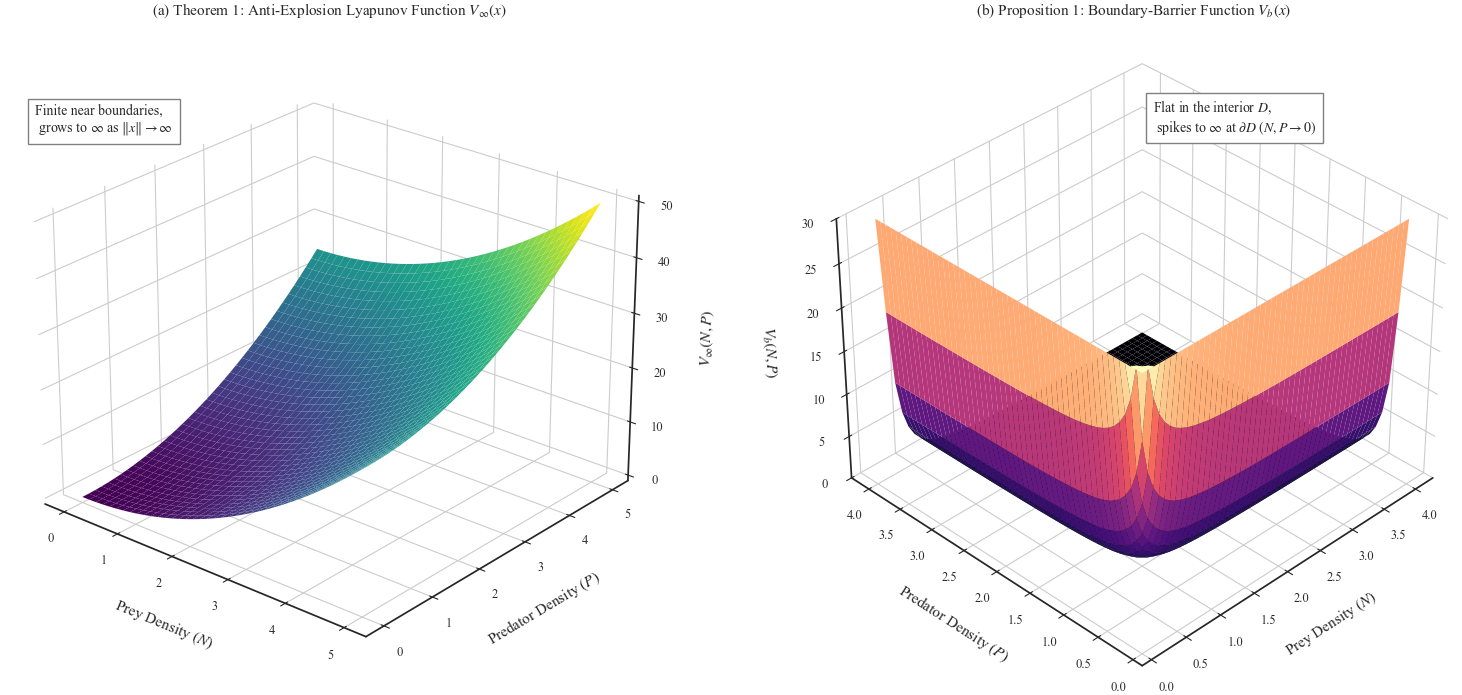

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display, IFrame

# ==========================================
# Output paths
# ==========================================
desktop = Path(r"C:\Users\lenovo\OneDrive - Northeastern University\桌面")
desktop.mkdir(parents=True, exist_ok=True)

eps_path = desktop / "Fig4.eps"
pdf_path = desktop / "Fig4_preview.pdf"

# ==========================================
# Figure Setup (PLOS-friendly style)
# ==========================================
plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "mathtext.fontset": "stix",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
    "axes.unicode_minus": False,
})

# Create a 1x2 grid for 3D subplots
fig = plt.figure(figsize=(16, 7), constrained_layout=True)
ax1 = fig.add_subplot(121, projection='3d')
ax2 = fig.add_subplot(122, projection='3d')

# ==========================================
# Panel (a): Preventing Interior Explosion (Theorem 1)
# Function V_inf(x) = N^2 + P^2 (Bowl shape)
# ==========================================
N_inf = np.linspace(0, 5, 40)
P_inf = np.linspace(0, 5, 40)
N_inf, P_inf = np.meshgrid(N_inf, P_inf)
V_inf = N_inf**2 + P_inf**2

surf1 = ax1.plot_surface(
    N_inf, P_inf, V_inf,
    cmap='viridis',
    edgecolor='none',
    linewidth=0,
    antialiased=True,
    rstride=1,
    cstride=1,
    alpha=1.0
)

ax1.set_title(r'(a) Theorem 1: Anti-Explosion Lyapunov Function $V_\infty(x)$', pad=14)
ax1.set_xlabel(r'Prey Density ($N$)', labelpad=10)
ax1.set_ylabel(r'Predator Density ($P$)', labelpad=10)
ax1.set_zlabel(r'$V_\infty(N, P)$', labelpad=10)

ax1.view_init(elev=25, azim=-50)
ax1.set_box_aspect((1, 1, 0.75))

# White panes for cleaner EPS output
for axis in [ax1.xaxis, ax1.yaxis, ax1.zaxis]:
    axis.set_pane_color((1.0, 1.0, 1.0, 1.0))

ax1.text2D(
    0.05, 0.85,
    r'Finite near boundaries,' '\n' r' grows to $\infty$ as $\|x\| \to \infty$',
    transform=ax1.transAxes, fontsize=10,
    bbox=dict(facecolor='white', edgecolor='gray', alpha=1.0, pad=5)
)

# ==========================================
# Panel (b): Positivity Invariance Barrier (Proposition 1)
# Function V_b(x) = 1/N^2 + 1/P^2 (Sharp boundary cliff)
# ==========================================
N_b = np.linspace(0.15, 4, 50)
P_b = np.linspace(0.15, 4, 50)
N_b, P_b = np.meshgrid(N_b, P_b)

V_b = 1 / (N_b**2) + 1 / (P_b**2)
Z_max = 30
V_b = np.clip(V_b, 0, Z_max)

surf2 = ax2.plot_surface(
    N_b, P_b, V_b,
    cmap='magma',
    edgecolor='none',
    linewidth=0,
    antialiased=True,
    rstride=1,
    cstride=1,
    alpha=1.0
)

ax2.set_title(r'(b) Proposition 1: Boundary-Barrier Function $V_b(x)$', pad=14)
ax2.set_xlabel(r'Prey Density ($N$)', labelpad=10)
ax2.set_ylabel(r'Predator Density ($P$)', labelpad=10)
ax2.set_zlabel(r'$V_b(N, P)$', labelpad=10)
ax2.set_zlim(0, Z_max)

ax2.view_init(elev=35, azim=-135)
ax2.set_box_aspect((1, 1, 0.75))

for axis in [ax2.xaxis, ax2.yaxis, ax2.zaxis]:
    axis.set_pane_color((1.0, 1.0, 1.0, 1.0))

ax2.text2D(
    0.53, 0.85,
    r'Flat in the interior $D$,' '\n' r' spikes to $\infty$ at $\partial D$ $(N,P \to 0)$',
    transform=ax2.transAxes, fontsize=10,
    bbox=dict(facecolor='white', edgecolor='gray', alpha=1.0, pad=5)
)

# ==========================================
# Save EPS + PDF preview
# ==========================================
fig.savefig(pdf_path, format='pdf')
fig.savefig(eps_path, format='eps')

display(IFrame(str(pdf_path), width=1100, height=700))
plt.show()

Numerical simulations for stochastic R-M paper
Generating Figure 6: Covariance ellipses ...


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


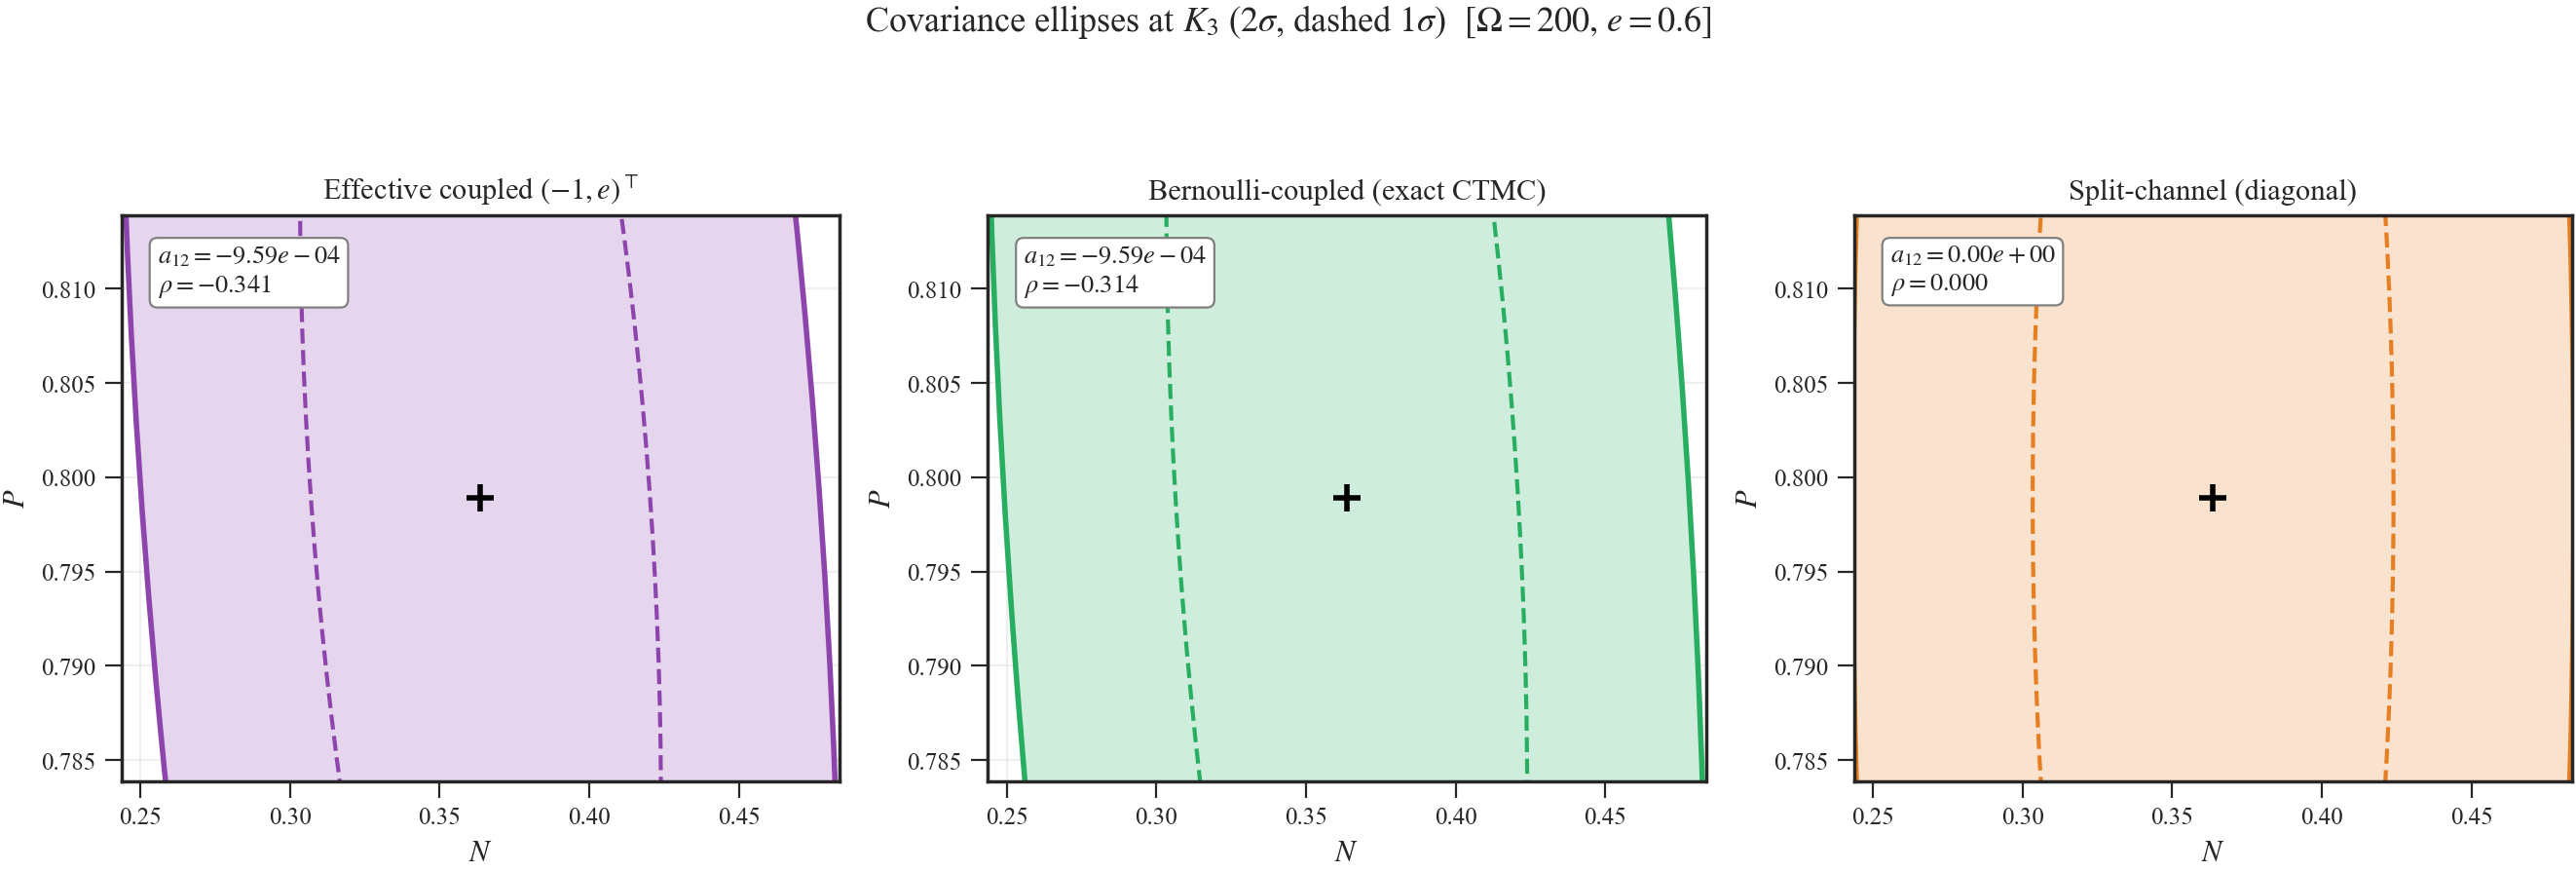

Saved: C:\Users\lenovo\OneDrive - Northeastern University\桌面\Fig6_covariance_ellipses.eps
Preview: C:\Users\lenovo\OneDrive - Northeastern University\桌面\Fig6_covariance_ellipses_preview.pdf
Generating Figure 7: Cross-covariance heatmap ...


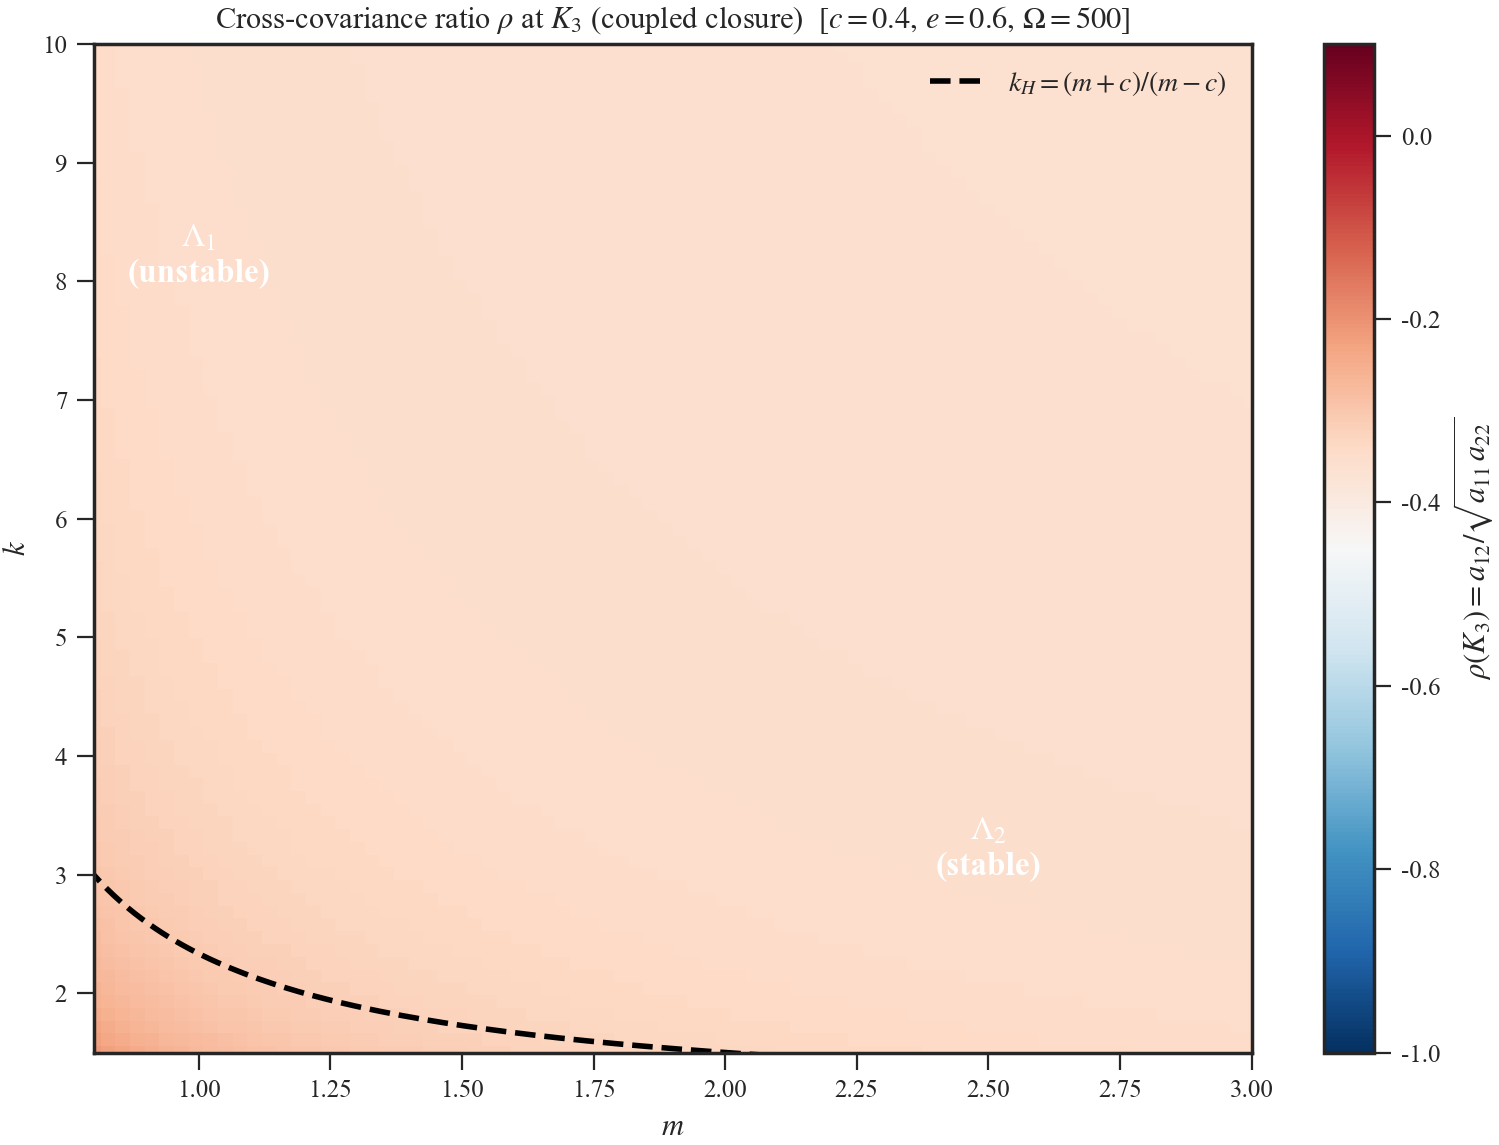

Saved: C:\Users\lenovo\OneDrive - Northeastern University\桌面\Fig7_crosscov_heatmap.eps
Preview: C:\Users\lenovo\OneDrive - Northeastern University\桌面\Fig7_crosscov_heatmap_preview.pdf
Generating Figure 8: Hopf regime comparison ...


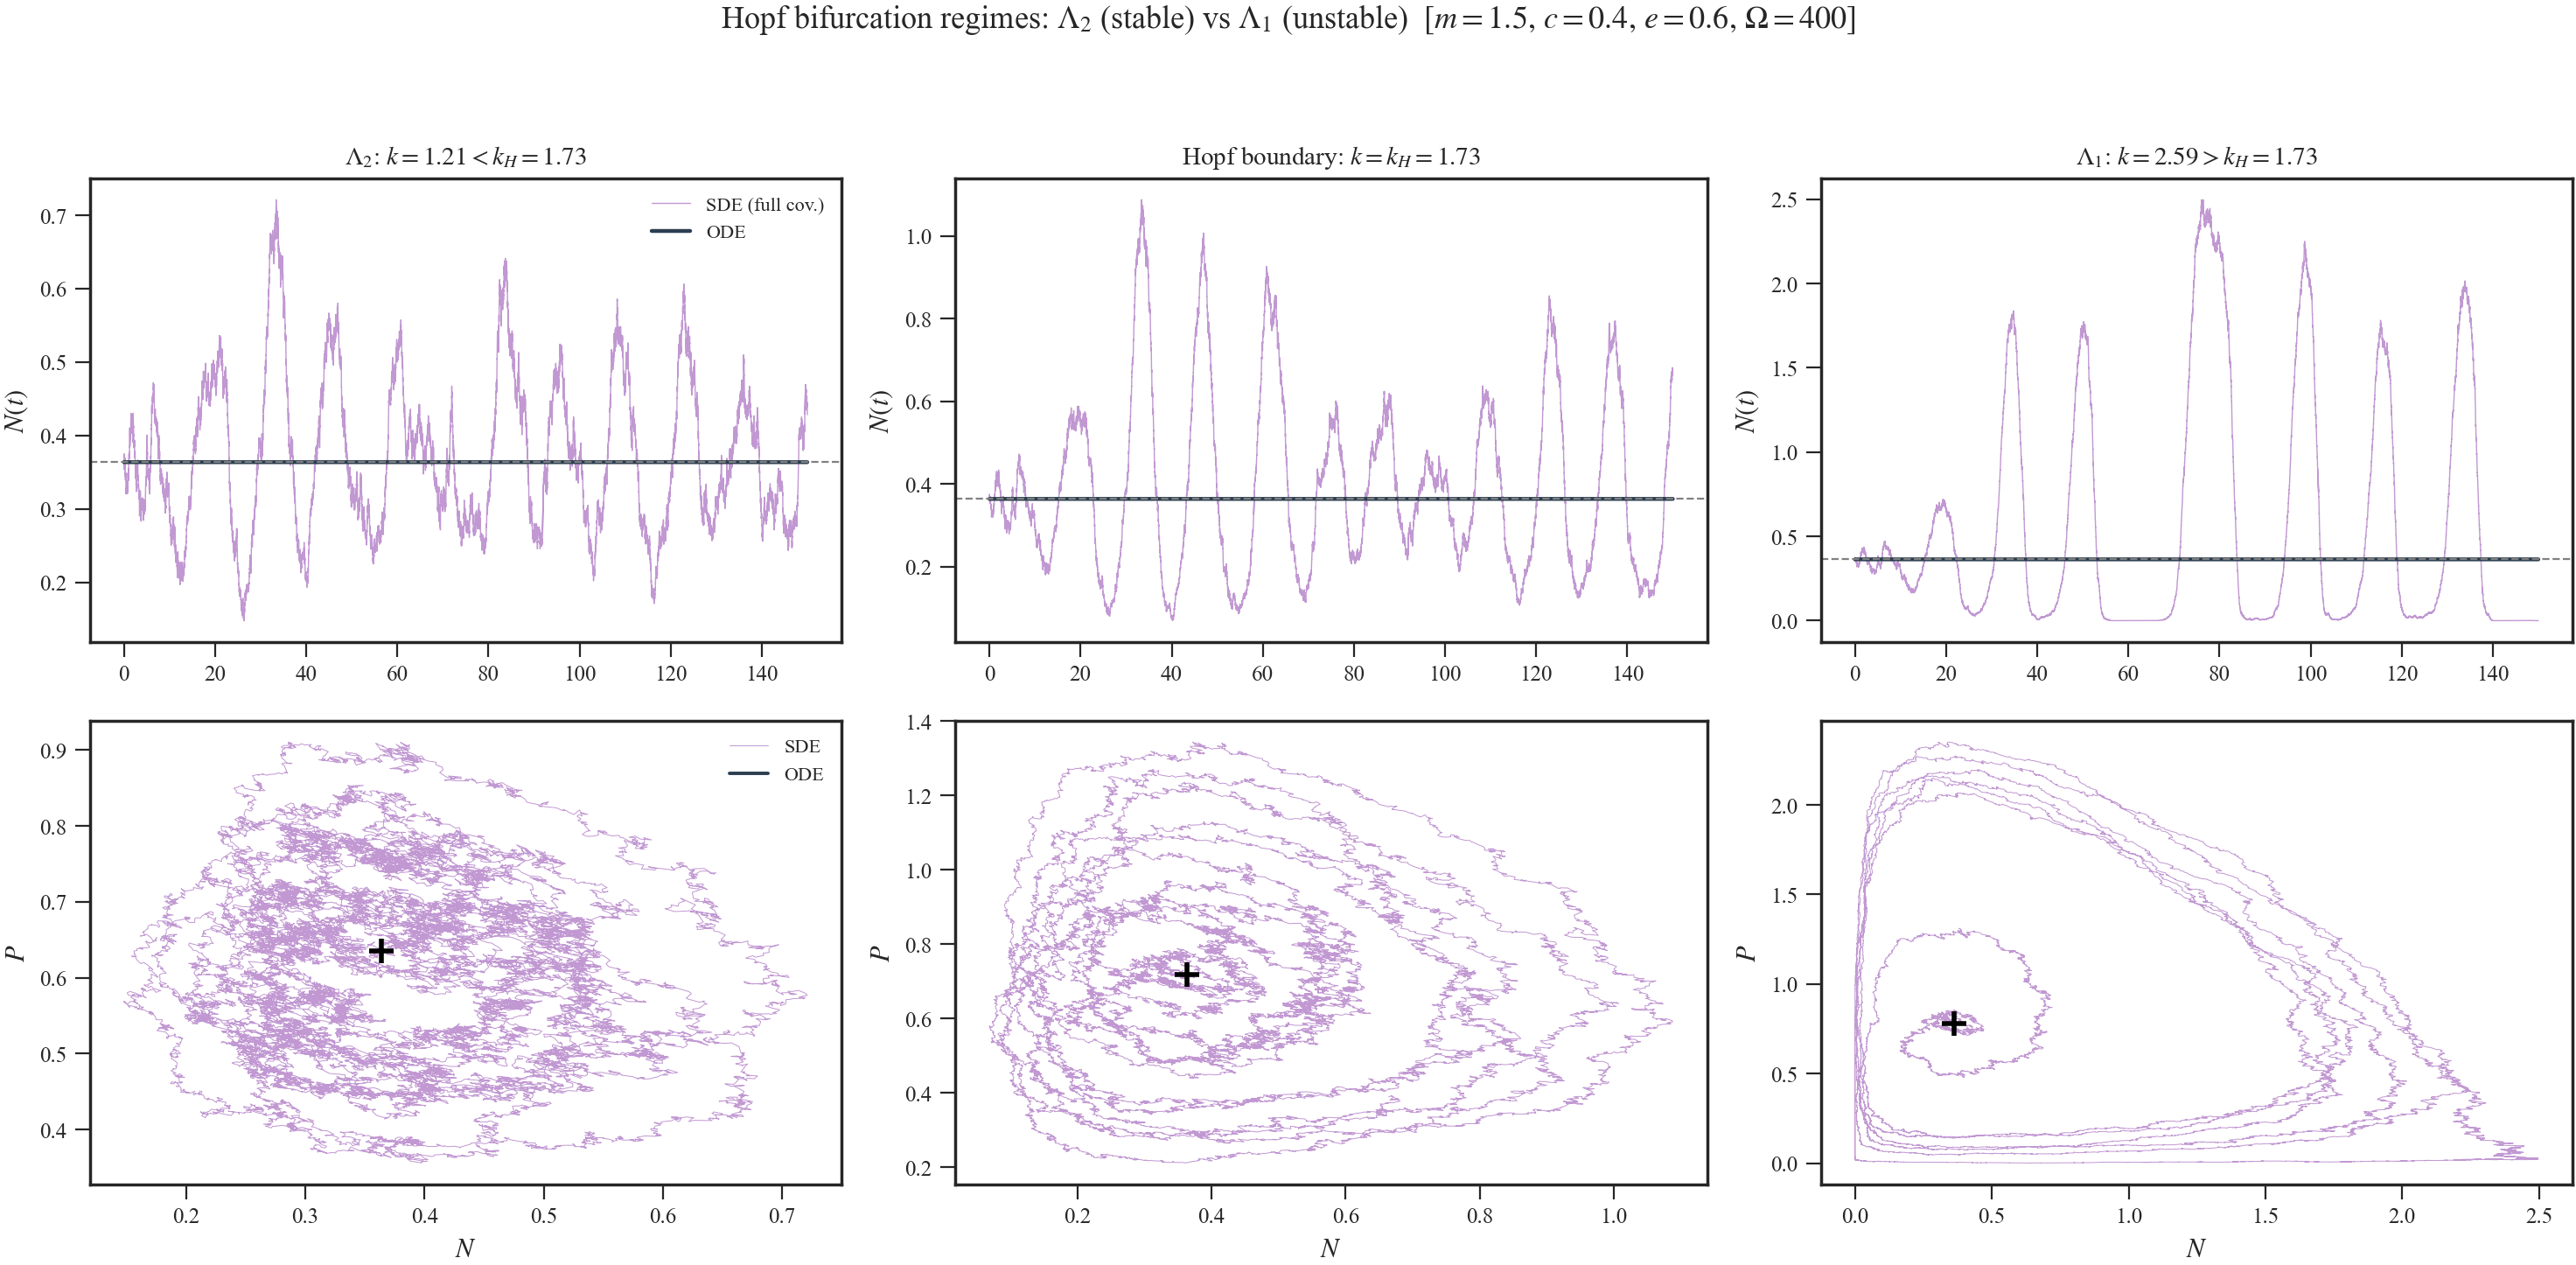

Saved: C:\Users\lenovo\OneDrive - Northeastern University\桌面\Fig8_hopf_regimes.eps
Preview: C:\Users\lenovo\OneDrive - Northeastern University\桌面\Fig8_hopf_regimes_preview.pdf
Generating Figure 9: Boundary analysis ...


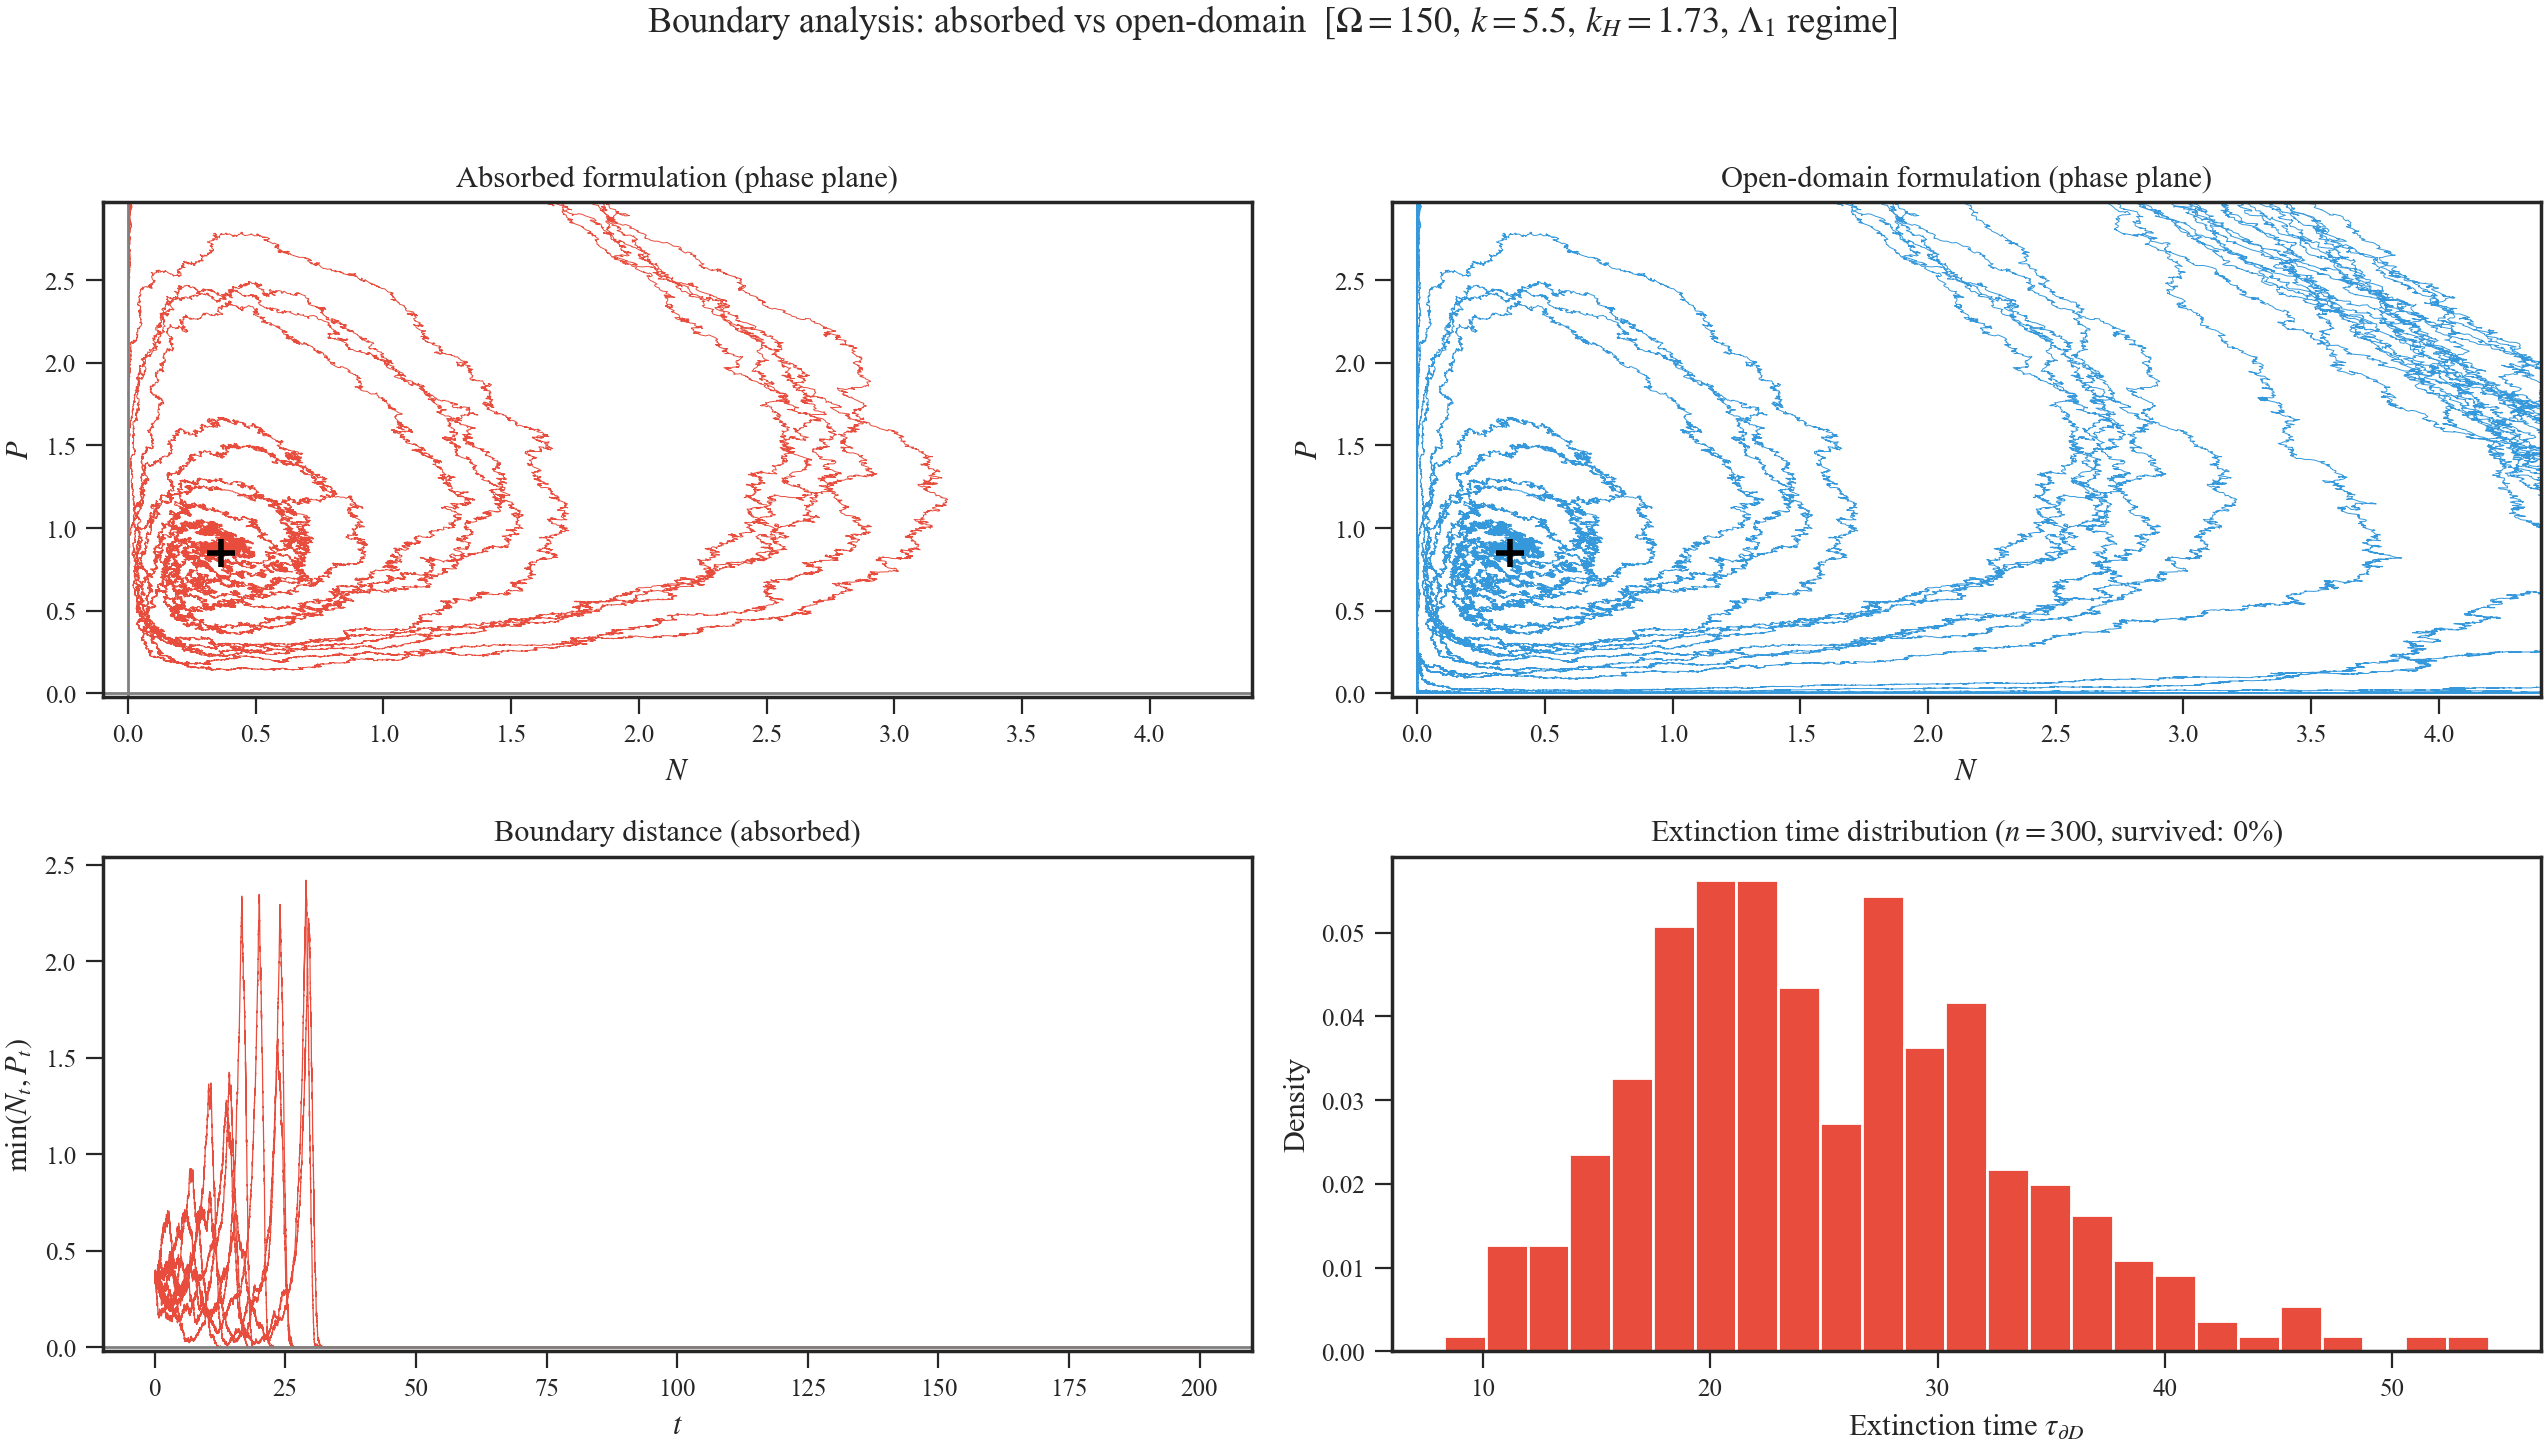

Saved: C:\Users\lenovo\OneDrive - Northeastern University\桌面\Fig9_boundary_analysis.eps
Preview: C:\Users\lenovo\OneDrive - Northeastern University\桌面\Fig9_boundary_analysis_preview.pdf
All figures generated successfully.


In [ ]:
"""
Numerical Simulations for the Mechanistic Stochastic Rosenzweig–MacArthur Paper.

This script generates figures for the "Numerical Simulation" section.

Output:
  - EPS files on the desktop (final submission)
  - PDF preview files on the desktop (for notebook inspection)
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Ellipse
from scipy.integrate import solve_ivp
from scipy.linalg import sqrtm
import warnings
from pathlib import Path
from IPython.display import display, IFrame
import matplotlib.colors as mcolors

warnings.filterwarnings('ignore')

# ============================================================
# Output directory
# ============================================================
DESKTOP = Path(r"C:\Users\lenovo\OneDrive - Northeastern University\桌面")
DESKTOP.mkdir(parents=True, exist_ok=True)

def export_figure(fig, stem):
    """
    Save final EPS to desktop and PDF preview to desktop.
    Also display the PDF preview below the cell.
    """
    pdf_path = DESKTOP / f"{stem}_preview.pdf"
    eps_path = DESKTOP / f"{stem}.eps"
    fig.savefig(pdf_path, format="pdf", bbox_inches="tight", pad_inches=0.02)
    fig.savefig(eps_path, format="eps", bbox_inches="tight", pad_inches=0.02)
    display(IFrame(str(pdf_path), width=1100, height=700))
    plt.show()
    plt.close(fig)
    print(f"Saved: {eps_path}")
    print(f"Preview: {pdf_path}")

def blend_with_white(color, blend=0.75):
    """
    Make an opaque pastel version of a color.
    This avoids alpha transparency, which is safer for EPS.
    """
    rgb = np.array(mcolors.to_rgb(color))
    return tuple((1 - blend) * rgb + blend * np.ones(3))

# ============================================================
# Global style
# ============================================================
plt.rcParams.update({
    "font.size": 10.5,
    "axes.labelsize": 11,
    "axes.titlesize": 11,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "figure.dpi": 200,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "font.family": "Times New Roman",
    "mathtext.fontset": "stix",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "axes.unicode_minus": False,
})

# Color palette
C_ODE    = '#2c3e50'
C_PREY   = '#2980b9'
C_PRED   = '#c0392b'
C_FULL   = '#8e44ad'
C_DIAG   = '#e67e22'
C_SSA    = '#27ae60'
C_ABS    = '#e74c3c'
C_OPEN   = '#3498db'

# ============================================================
# Model functions
# ============================================================
def rm_drift(x, m, c, k):
    """Deterministic R-M drift b(x)."""
    N, P = x
    dN = N * (1 - N / k) - m * N * P / (1 + N)
    dP = P * (-c + m * N / (1 + N))
    return np.array([dN, dP])

def f_pred(N, P, m):
    """Predation intensity f_pred(x) = mNP/(1+N)."""
    return m * N * P / (1 + N)

def covariance_full(x, m, c, k, e, Omega):
    """Full-covariance matrix a(x) under coupled closure (effective (-1,e))."""
    N, P = x
    fp = f_pred(N, P, m)
    a = np.zeros((2, 2))
    a[0, 0] += N
    a[0, 0] += N**2 / k
    a[1, 1] += c * P
    a[0, 0] += fp
    a[0, 1] += -e * fp
    a[1, 0] += -e * fp
    a[1, 1] += e**2 * fp
    return a / Omega

def covariance_bernoulli(x, m, c, k, e, Omega):
    """Full-covariance matrix a(x) under exact Bernoulli-coupled closure."""
    N, P = x
    fp = f_pred(N, P, m)
    a = np.zeros((2, 2))
    a[0, 0] += N
    a[0, 0] += N**2 / k
    a[1, 1] += c * P
    a[0, 0] += fp
    a[0, 1] += -e * fp
    a[1, 0] += -e * fp
    a[1, 1] += e * fp
    return a / Omega

def covariance_split(x, m, c, k, e, Omega):
    """Diagonal covariance matrix a(x) under split-channel closure."""
    N, P = x
    fp = f_pred(N, P, m)
    a = np.zeros((2, 2))
    a[0, 0] += N
    a[0, 0] += N**2 / k
    a[1, 1] += c * P
    a[0, 0] += fp
    a[1, 1] += e * fp
    return a / Omega

def coexistence_eq(m, c, k):
    """Coexistence equilibrium K3 = (N*, P*)."""
    N_star = c / (m - c)
    P_star = (k * (m - c) - c) / (k * (m - c)**2)
    return N_star, P_star

def hopf_threshold(m, c):
    """Hopf threshold k_H = (m+c)/(m-c)."""
    return (m + c) / (m - c)

def jacobian_at_eq(m, c, k):
    """Jacobian at K3."""
    Ns, Ps = coexistence_eq(m, c, k)
    J = np.array([
        [1 - 2 * Ns / k - m * Ps / (1 + Ns)**2, -m * Ns / (1 + Ns)],
        [m * Ps / (1 + Ns)**2, -c + m * Ns / (1 + Ns)]
    ])
    return J

# ============================================================
# Gillespie SSA
# ============================================================
def gillespie_ssa(m, c, k, e, Omega, x0, T_end, seed=None):
    rng = np.random.default_rng(seed)
    X = np.array([int(x0[0] * Omega), int(x0[1] * Omega)])
    t = 0.0
    times = [t]
    states = [X.copy() / Omega]

    while t < T_end:
        N_count, P_count = X
        N_d, P_d = N_count / Omega, P_count / Omega

        lam = np.zeros(5)
        lam[0] = Omega * N_d
        lam[1] = Omega * N_d**2 / k
        lam[2] = Omega * c * P_d
        fp = m * N_d * P_d / (1 + N_d) if N_d > 0 else 0.0
        lam[3] = Omega * e * fp
        lam[4] = Omega * (1 - e) * fp

        lam_total = lam.sum()
        if lam_total <= 0:
            break

        dt = rng.exponential(1.0 / lam_total)
        t += dt
        if t > T_end:
            break

        r = rng.random() * lam_total
        cum = np.cumsum(lam)
        idx = np.searchsorted(cum, r)

        if idx == 0:
            X[0] += 1
        elif idx == 1:
            X[0] = max(X[0] - 1, 0)
        elif idx == 2:
            X[1] = max(X[1] - 1, 0)
        elif idx == 3:
            X[0] = max(X[0] - 1, 0)
            X[1] += 1
        elif idx == 4:
            X[0] = max(X[0] - 1, 0)

        if X[0] == 0 or X[1] == 0:
            times.append(t)
            states.append(X.copy() / Omega)
            break

        times.append(t)
        states.append(X.copy() / Omega)

    return np.array(times), np.array(states)

# ============================================================
# Euler–Maruyama SDE solver
# ============================================================
def euler_maruyama(m, c, k, e, Omega, x0, T_end, dt, cov_func, seed=None, absorbed=False):
    rng = np.random.default_rng(seed)
    nsteps = int(T_end / dt)
    x = np.array(x0, dtype=float)
    traj = np.zeros((nsteps + 1, 2))
    traj[0] = x.copy()
    times = np.linspace(0, T_end, nsteps + 1)
    frozen = False
    freeze_time = None

    for i in range(nsteps):
        if frozen:
            traj[i + 1] = traj[i]
            continue

        N, P = x
        if N <= 0 or P <= 0:
            if absorbed:
                frozen = True
                freeze_time = times[i]
                traj[i + 1] = x.copy()
                continue
            else:
                N = max(N, 1e-12)
                P = max(P, 1e-12)
                x = np.array([N, P])

        b = rm_drift(x, m, c, k)
        a = cov_func(x, m, c, k, e, Omega)

        try:
            L = np.linalg.cholesky(a + 1e-15 * np.eye(2))
        except np.linalg.LinAlgError:
            eigvals, eigvecs = np.linalg.eigh(a)
            eigvals = np.maximum(eigvals, 0)
            L = eigvecs @ np.diag(np.sqrt(eigvals))

        dW = rng.standard_normal(2) * np.sqrt(dt)
        x_new = x + b * dt + L @ dW

        if absorbed and (x_new[0] <= 0 or x_new[1] <= 0):
            frozen = True
            freeze_time = times[i + 1]
            x_new = np.maximum(x_new, 0.0)

        x = x_new
        traj[i + 1] = x.copy()

    return times, traj, freeze_time

# ============================================================
# ODE solver
# ============================================================
def solve_ode(m, c, k, x0, T_end, npts=2000):
    def rhs(t, y):
        return rm_drift(y, m, c, k)
    sol = solve_ivp(
        rhs, [0, T_end], x0,
        t_eval=np.linspace(0, T_end, npts),
        method='RK45', rtol=1e-10, atol=1e-12
    )
    return sol.t, sol.y.T

# ============================================================
# FIGURE 6: Covariance ellipses at K3
# ============================================================
def figure6_covariance_ellipses():
    print("Generating Figure 6: Covariance ellipses ...")
    m, c, k, e = 1.5, 0.4, 3.0, 0.6
    Omega = 200
    Ns, Ps = coexistence_eq(m, c, k)
    x_star = np.array([Ns, Ps])

    a_full = covariance_full(x_star, m, c, k, e, Omega)
    a_bern = covariance_bernoulli(x_star, m, c, k, e, Omega)
    a_split = covariance_split(x_star, m, c, k, e, Omega)

    fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.5))

    closures = [
        (a_full,  r'Effective coupled $(-1,e)^\top$', C_FULL),
        (a_bern,  r'Bernoulli-coupled (exact CTMC)', C_SSA),
        (a_split, r'Split-channel (diagonal)', C_DIAG),
    ]

    scale_factor = 2.0

    for ax, (a_mat, title, color) in zip(axes, closures):
        eigvals, eigvecs = np.linalg.eigh(a_mat)
        eigvals = np.maximum(eigvals, 0)
        angle = np.degrees(np.arctan2(eigvecs[1, 1], eigvecs[0, 1]))
        width = 2 * scale_factor * np.sqrt(eigvals[1])
        height = 2 * scale_factor * np.sqrt(eigvals[0])

        fill_color = blend_with_white(color, blend=0.78)

        ell = Ellipse(
            xy=(Ns, Ps), width=width, height=height, angle=angle,
            edgecolor=color, facecolor=fill_color, lw=2.0
        )
        ax.add_patch(ell)

        ell1 = Ellipse(
            xy=(Ns, Ps), width=width / 2, height=height / 2, angle=angle,
            edgecolor=color, facecolor='none', lw=1.5, ls='--'
        )
        ax.add_patch(ell1)

        ax.plot(Ns, Ps, 'k+', ms=10, mew=2)
        ax.set_xlabel(r'$N$')
        ax.set_ylabel(r'$P$')
        ax.set_title(title, fontsize=11)

        a12 = a_mat[0, 1]
        rho = a12 / np.sqrt(a_mat[0, 0] * a_mat[1, 1]) if a_mat[0, 0] > 0 and a_mat[1, 1] > 0 else 0
        ax.text(
            0.05, 0.95,
            rf'$a_{{12}} = {a12:.2e}$' + '\n' + rf'$\rho = {rho:.3f}$',
            transform=ax.transAxes, va='top', fontsize=9.5,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', linewidth=0.8)
        )

        margin_N = 0.12
        margin_P = 0.015
        ax.set_xlim(Ns - margin_N, Ns + margin_N)
        ax.set_ylim(Ps - margin_P, Ps + margin_P)
        ax.set_aspect('auto')
        ax.grid(True, alpha=0.3)

    fig.suptitle(
        rf'Covariance ellipses at $K_3$ ($2\sigma$, dashed $1\sigma$)  '
        rf'[$\Omega={Omega},\, e={e}$]',
        fontsize=13, y=1.02
    )
    fig.tight_layout(rect=[0, 0, 1, 0.94])
    export_figure(fig, "Fig6_covariance_ellipses")

# ============================================================
# FIGURE 7: Cross-covariance ratio rho across parameter space
# ============================================================
def truncate_cmap(cmap_name='RdBu_r', minval=0.18, maxval=0.92, n=256):
    base = plt.get_cmap(cmap_name)
    colors = base(np.linspace(minval, maxval, n))
    return mcolors.LinearSegmentedColormap.from_list(f"trunc_{cmap_name}", colors)

def figure7_crosscov_heatmap():
    print("Generating Figure 7: Cross-covariance heatmap ...")
    c = 0.4
    Omega = 500

    m_vals = np.linspace(0.8, 3.0, 80)
    k_vals = np.linspace(1.5, 10.0, 80)

    rho_map = np.full((len(k_vals), len(m_vals)), np.nan)

    for i, kk in enumerate(k_vals):
        for j, mm in enumerate(m_vals):
            e = 0.6
            if mm <= c:
                continue
            Ns = c / (mm - c)
            Ps_num = kk * (mm - c) - c
            Ps_den = kk * (mm - c) ** 2
            if Ps_num <= 0:
                continue
            Ps = Ps_num / Ps_den

            x_star = np.array([Ns, Ps])
            a = covariance_full(x_star, mm, c, kk, e, Omega)
            if a[0, 0] > 0 and a[1, 1] > 0:
                rho_map[i, j] = a[0, 1] / np.sqrt(a[0, 0] * a[1, 1])

    fig, ax = plt.subplots(1, 1, figsize=(8, 6))

    M, K = np.meshgrid(m_vals, k_vals)

    # lighter color map
    light_cmap = truncate_cmap('RdBu_r', minval=0.18, maxval=0.92)

    im = ax.pcolormesh(
        M, K, rho_map,
        cmap=light_cmap,
        vmin=-1, vmax=0.1,
        shading='auto'
    )

    cbar = fig.colorbar(im, ax=ax, label=r'$\rho(K_3) = a_{12}/\sqrt{a_{11}\,a_{22}}$')
    cbar.ax.tick_params(labelsize=9)

    m_line = np.linspace(c + 0.01, 3.0, 200)
    kH_line = (m_line + c) / (m_line - c)
    ax.plot(m_line, kH_line, 'k--', lw=2, label=r'$k_H = (m+c)/(m-c)$')

    ax.set_xlabel(r'$m$')
    ax.set_ylabel(r'$k$')
    ax.set_title(
        rf'Cross-covariance ratio $\rho$ at $K_3$ (coupled closure)  '
        rf'[$c={c},\, e=0.6,\, \Omega={Omega}$]'
    )
    ax.legend(fontsize=10, loc='upper right')
    ax.set_xlim(m_vals[0], m_vals[-1])
    ax.set_ylim(k_vals[0], k_vals[-1])

    # black labels in the two regions
    ax.text(0.98, 1.82, r'$\Lambda_2$' + '\n(stable)',
            fontsize=12, ha='center', va='center',
            color='black', fontweight='bold',
            bbox=dict(facecolor='white', edgecolor='none', pad=1.5))

    ax.text(2.45, 8.15, r'$\Lambda_1$' + '\n(unstable)',
            fontsize=12, ha='center', va='center',
            color='black', fontweight='bold',
            bbox=dict(facecolor='white', edgecolor='none', pad=1.5))

    fig.tight_layout()
    export_figure(fig, "Fig7_crosscov_heatmap")
    
# ============================================================
# FIGURE 8: Hopf bifurcation regime comparison
# ============================================================
def figure8_hopf_regimes():
    print("Generating Figure 8: Hopf regime comparison ...")
    m, c, e = 1.5, 0.4, 0.6
    Omega = 400
    kH = hopf_threshold(m, c)
    k_stable = kH * 0.7
    k_unstable = kH * 1.5
    T_end = 150
    dt = 0.005

    fig, axes = plt.subplots(2, 3, figsize=(15, 7.5))

    full_light = blend_with_white(C_FULL, blend=0.45)

    for col, (kk, regime_label) in enumerate([
        (k_stable, rf'$\Lambda_2$: $k={k_stable:.2f} < k_H={kH:.2f}$'),
        (kH,       rf'Hopf boundary: $k = k_H = {kH:.2f}$'),
        (k_unstable, rf'$\Lambda_1$: $k={k_unstable:.2f} > k_H={kH:.2f}$'),
    ]):
        Ns, Ps = coexistence_eq(m, c, kk)
        x0 = [Ns, Ps]

        t_ode, y_ode = solve_ode(m, c, kk, x0, T_end)
        t_sde, traj_sde, _ = euler_maruyama(
            m, c, kk, e, Omega, x0, T_end, dt, covariance_full, seed=77
        )

        axes[0, col].plot(t_sde, traj_sde[:, 0], color=full_light, lw=0.5,
                          label='SDE (full cov.)')
        axes[0, col].plot(t_ode, y_ode[:, 0], color=C_ODE, lw=1.6, label='ODE')
        axes[0, col].axhline(Ns, color='gray', ls='--', lw=0.8)
        axes[0, col].set_ylabel(r'$N(t)$')
        axes[0, col].set_title(regime_label, fontsize=10.5)
        if col == 0:
            axes[0, col].legend(fontsize=8, loc='upper right')

        axes[1, col].plot(traj_sde[:, 0], traj_sde[:, 1], color=full_light, lw=0.35, label='SDE')
        axes[1, col].plot(y_ode[:, 0], y_ode[:, 1], color=C_ODE, lw=1.4, label='ODE')
        axes[1, col].plot(Ns, Ps, 'k+', ms=10, mew=2, zorder=5)
        axes[1, col].set_xlabel(r'$N$')
        axes[1, col].set_ylabel(r'$P$')
        if col == 0:
            axes[1, col].legend(fontsize=8)

    fig.suptitle(
        rf'Hopf bifurcation regimes: $\Lambda_2$ (stable) vs $\Lambda_1$ (unstable)  '
        rf'[$m={m},\, c={c},\, e={e},\, \Omega={Omega}$]',
        fontsize=13
    )
    fig.tight_layout(rect=[0, 0, 1, 0.94])
    export_figure(fig, "Fig8_hopf_regimes")

# ============================================================
# FIGURE 9: Boundary proximity — absorbed vs open-domain
# ============================================================
def figure9_boundary_analysis():
    print("Generating Figure 9: Boundary analysis ...")
    m, c, k, e = 1.5, 0.4, 5.5, 0.6
    Omega = 150
    T_end = 200
    dt = 0.002
    Ns, Ps = coexistence_eq(m, c, k)
    x0 = [Ns, Ps]

    fig, axes = plt.subplots(2, 2, figsize=(13, 7.5))

    n_paths = 8

    # Absorbed paths
    freeze_times_abs = []
    for i in range(n_paths):
        t, traj, ft = euler_maruyama(
            m, c, k, e, Omega, x0, T_end, dt,
            covariance_full, seed=200 + i, absorbed=True
        )
        if ft is not None:
            freeze_times_abs.append(ft)
        color = C_ABS
        axes[0, 0].plot(traj[:, 0], traj[:, 1], color=color, lw=0.35)

    axes[0, 0].plot(Ns, Ps, 'k+', ms=10, mew=2, zorder=5)
    axes[0, 0].axvline(0, color='gray', lw=1)
    axes[0, 0].axhline(0, color='gray', lw=1)
    axes[0, 0].set_xlabel(r'$N$')
    axes[0, 0].set_ylabel(r'$P$')
    axes[0, 0].set_title(r'Absorbed formulation (phase plane)')
    axes[0, 0].set_xlim(-0.1, max(Ns * 2.5, k * 0.8))
    axes[0, 0].set_ylim(-0.02, Ps * 3.5)

    # Open-domain paths
    for i in range(n_paths):
        t, traj, _ = euler_maruyama(
            m, c, k, e, Omega, x0, T_end, dt,
            covariance_full, seed=200 + i, absorbed=False
        )
        axes[0, 1].plot(traj[:, 0], traj[:, 1], color=C_OPEN, lw=0.35)

    axes[0, 1].plot(Ns, Ps, 'k+', ms=10, mew=2, zorder=5)
    axes[0, 1].set_xlabel(r'$N$')
    axes[0, 1].set_ylabel(r'$P$')
    axes[0, 1].set_title(r'Open-domain formulation (phase plane)')
    axes[0, 1].set_xlim(-0.1, max(Ns * 2.5, k * 0.8))
    axes[0, 1].set_ylim(-0.02, Ps * 3.5)

    # Minimum distance to boundary over time
    for i in range(n_paths):
        t_a, traj_a, ft_a = euler_maruyama(
            m, c, k, e, Omega, x0, T_end, dt,
            covariance_full, seed=200 + i, absorbed=True
        )
        min_dist = np.minimum(traj_a[:, 0], traj_a[:, 1])
        axes[1, 0].plot(t_a, min_dist, color=C_ABS, lw=0.45)

    axes[1, 0].axhline(0, color='gray', ls='-', lw=1)
    axes[1, 0].set_xlabel(r'$t$')
    axes[1, 0].set_ylabel(r'$\min(N_t, P_t)$')
    axes[1, 0].set_title('Boundary distance (absorbed)')
    axes[1, 0].set_ylim(-0.02, None)

    # Extinction time histogram
    n_mc = 300
    extinction_times = []
    survived = 0
    for i in range(n_mc):
        _, _, ft = euler_maruyama(
            m, c, k, e, Omega, x0, T_end, dt,
            covariance_full, seed=5000 + i, absorbed=True
        )
        if ft is not None:
            extinction_times.append(ft)
        else:
            survived += 1

    if len(extinction_times) > 3:
        axes[1, 1].hist(
            extinction_times, bins=25, color=C_ABS,
            edgecolor='white', density=True
        )
    axes[1, 1].set_xlabel(r'Extinction time $\tau_{\partial D}$')
    axes[1, 1].set_ylabel('Density')
    surv_frac = survived / n_mc
    axes[1, 1].set_title(
        rf'Extinction time distribution ($n={n_mc}$, survived: {surv_frac:.0%})'
    )

    kH = hopf_threshold(m, c)
    fig.suptitle(
        rf'Boundary analysis: absorbed vs open-domain  '
        rf'[$\Omega={Omega},\, k={k},\, k_H={kH:.2f}$, '
        + (r'$\Lambda_1$' if k > kH else r'$\Lambda_2$') + ' regime]',
        fontsize=13
    )
    fig.tight_layout(rect=[0, 0, 1, 0.94])
    export_figure(fig, "Fig9_boundary_analysis")

# ============================================================
# Run all figures
# ============================================================
if __name__ == '__main__':
    print("=" * 60)
    print("Numerical simulations for stochastic R-M paper")
    print("=" * 60)
    figure6_covariance_ellipses()
    figure7_crosscov_heatmap()
    figure8_hopf_regimes()
    figure9_boundary_analysis()
    print("=" * 60)
    print("All figures generated successfully.")
    print("=" * 60)